In [19]:
import sys

sys.path.append("..")

import pandas as pd

from src.visualization import (
    plot_topic_distribution,
    plot_sentiment_by_topic,
    plot_sentiment_dynamics,
    plot_topic_sentiment_heatmap,
    plot_sentiment_confidence,
    plot_topic_similarity
)

In [20]:
!pip install seaborn

In [21]:
df = pd.read_csv(
    "/Users/zhengbinheng/Desktop/topic-specific-sentiment/data/processed/sentiment_scores.csv"
)

print(df.shape)

df.head()

(32770, 13)


,Headlines,Time,Description,text,clean_text,length,topic,topic_name,sentiment,sentiment_score,positive_prob,negative_prob,neutral_prob
0,TikTok considers London and other locations fo...,2020-07-18,TikTok has been in discussions with the UK gov...,TikTok considers London and other locations fo...,tiktok considers london and other locations fo...,47,9,Mergers & Acquisitions,positive,1,0.514773,0.014931,0.470296
1,Disney cuts ad spending on Facebook amid growi...,2020-07-18,Walt Disney has become the latest company to ...,Disney cuts ad spending on Facebook amid growi...,disney cuts ad spending on facebook amid growi...,56,6,Big Tech & Digital Platforms,negative,-1,0.007725,0.966416,0.025859
2,Trail of missing Wirecard executive leads to B...,2020-07-18,Former Wirecard chief operating officer Jan M...,Trail of missing Wirecard executive leads to B...,trail of missing wirecard executive leads to b...,40,4,Automotive Industry & Corporate Leadership,negative,-1,0.011173,0.898517,0.090310
3,Twitter says attackers downloaded data from up...,2020-07-18,Twitter Inc said on Saturday that hackers were...,Twitter says attackers downloaded data from up...,twitter says attackers downloaded data from up...,47,6,Big Tech & Digital Platforms,neutral,0,0.041731,0.079068,0.879201
4,U.S. Republicans seek liability protections as...,2020-07-17,A battle in the U.S. Congress over a new coron...,U.S. Republicans seek liability protections as...,u s republicans seek liability protections as ...,50,3,US-China Trade War & Geopolitics,positive,1,0.439223,0.378891,0.181886


Basic Statistics

In [22]:
print(
    df["sentiment"]
    .value_counts()
)

print()

print(
    (
        df["sentiment"]
        .value_counts(normalize=True)
        * 100
    ).round(2)
)

sentiment
negative    15905
positive    10329
neutral      6536
Name: count, dtype: int64

sentiment
negative    48.54
positive    31.52
neutral     19.95
Name: proportion, dtype: float64


Topic Counts

In [23]:
topic_counts = (
    df["topic_name"]
    .value_counts()
)

topic_counts

topic_name
Macroeconomy & Financial Markets              3903
Big Tech & Digital Platforms                  3356
Automotive Industry & Corporate Leadership    3345
Mergers & Acquisitions                        3249
Financial Regulation & Corporate Scandals     2735
COVID-19, Manufacturing & Labor Markets       2654
Banking & Financial Services                  2493
International Trade & Economic Policy         2387
Corporate Earnings & Equity Markets           2379
Aviation & Air Transportation                 2247
US-China Trade War & Geopolitics              2177
Oil & Energy Markets                          1845
Name: count, dtype: int64

Figure 1: Topic Distribution

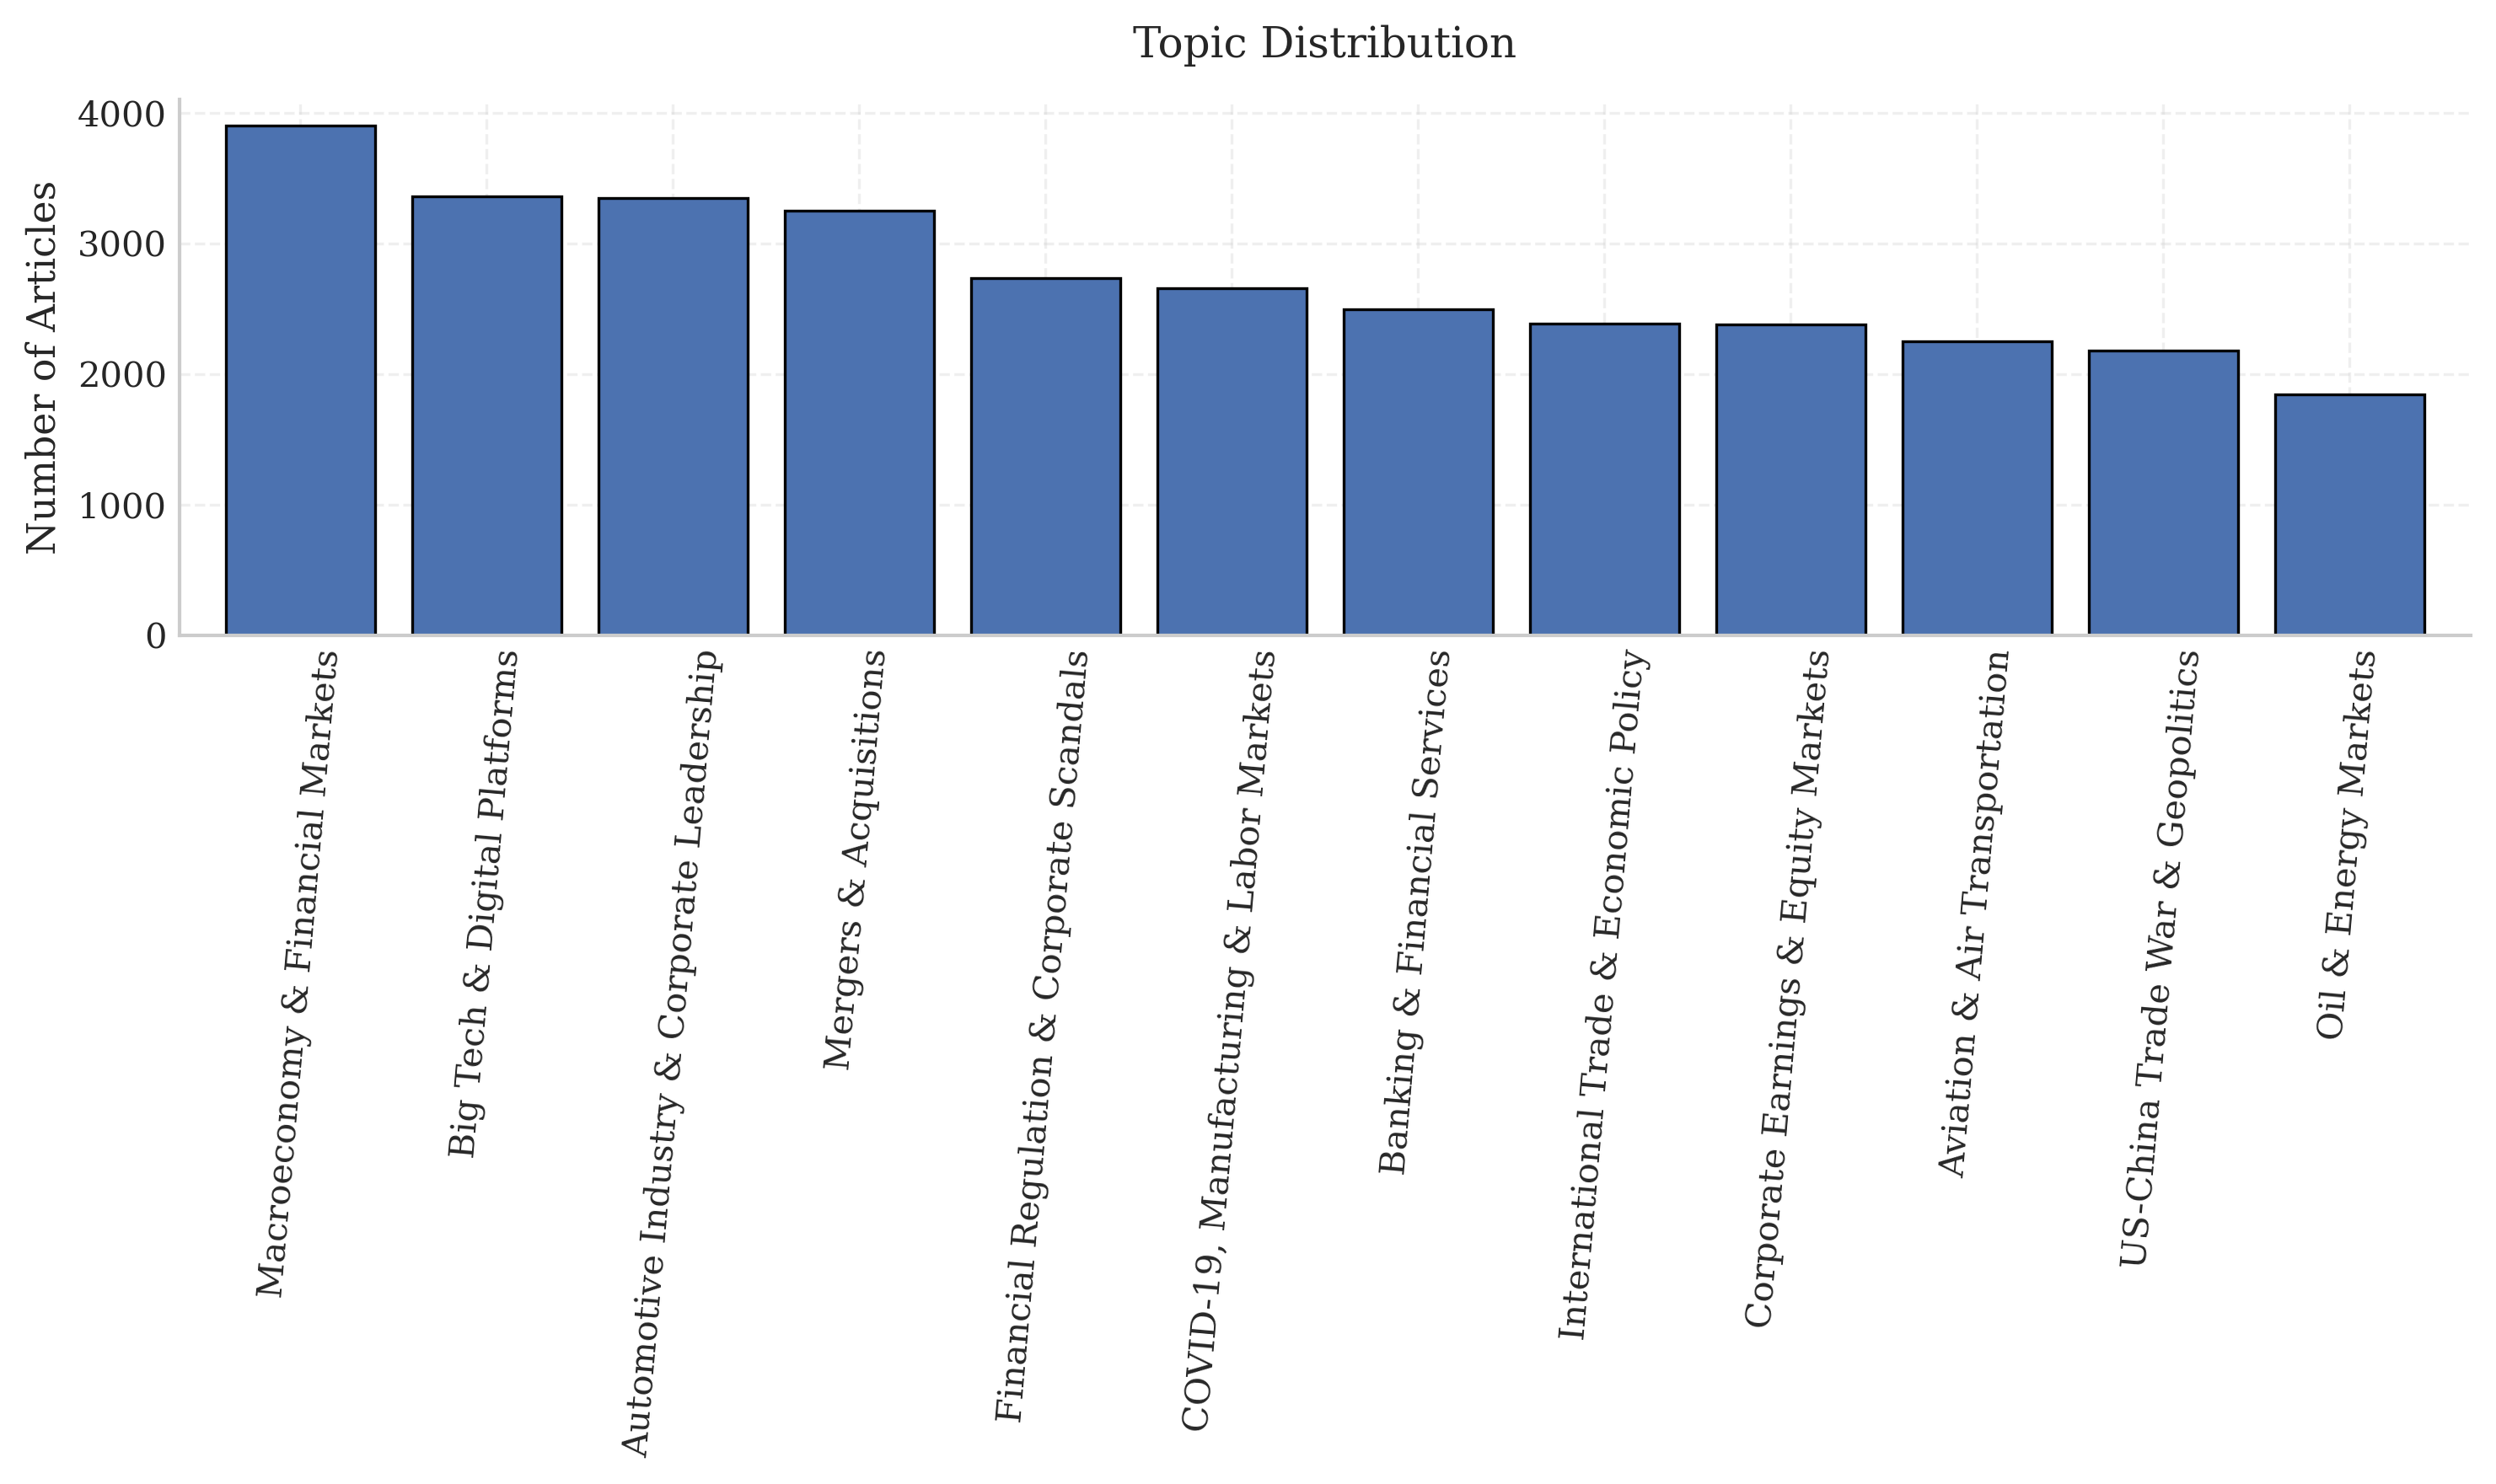

In [24]:
plot_topic_distribution(
    df,
    save_path=
    "/Users/zhengbinheng/Desktop/topic-specific-sentiment/results/figures/topic_distribution.png"
)

Average Sentiment

In [25]:
avg_sentiment = (
    df.groupby("topic_name")
      ["sentiment_score"]
      .mean()
      .sort_values()
)

avg_sentiment

topic_name
Financial Regulation & Corporate Scandals    -0.581718
COVID-19, Manufacturing & Labor Markets      -0.424642
Aviation & Air Transportation                -0.244326
US-China Trade War & Geopolitics             -0.224162
Banking & Financial Services                 -0.203369
Macroeconomy & Financial Markets             -0.194210
Automotive Industry & Corporate Leadership   -0.183259
Oil & Energy Markets                         -0.163686
Corporate Earnings & Equity Markets          -0.095839
Big Tech & Digital Platforms                 -0.042610
International Trade & Economic Policy         0.006703
Mergers & Acquisitions                        0.219760
Name: sentiment_score, dtype: float64

Figure 2: Average Sentiment by Topic

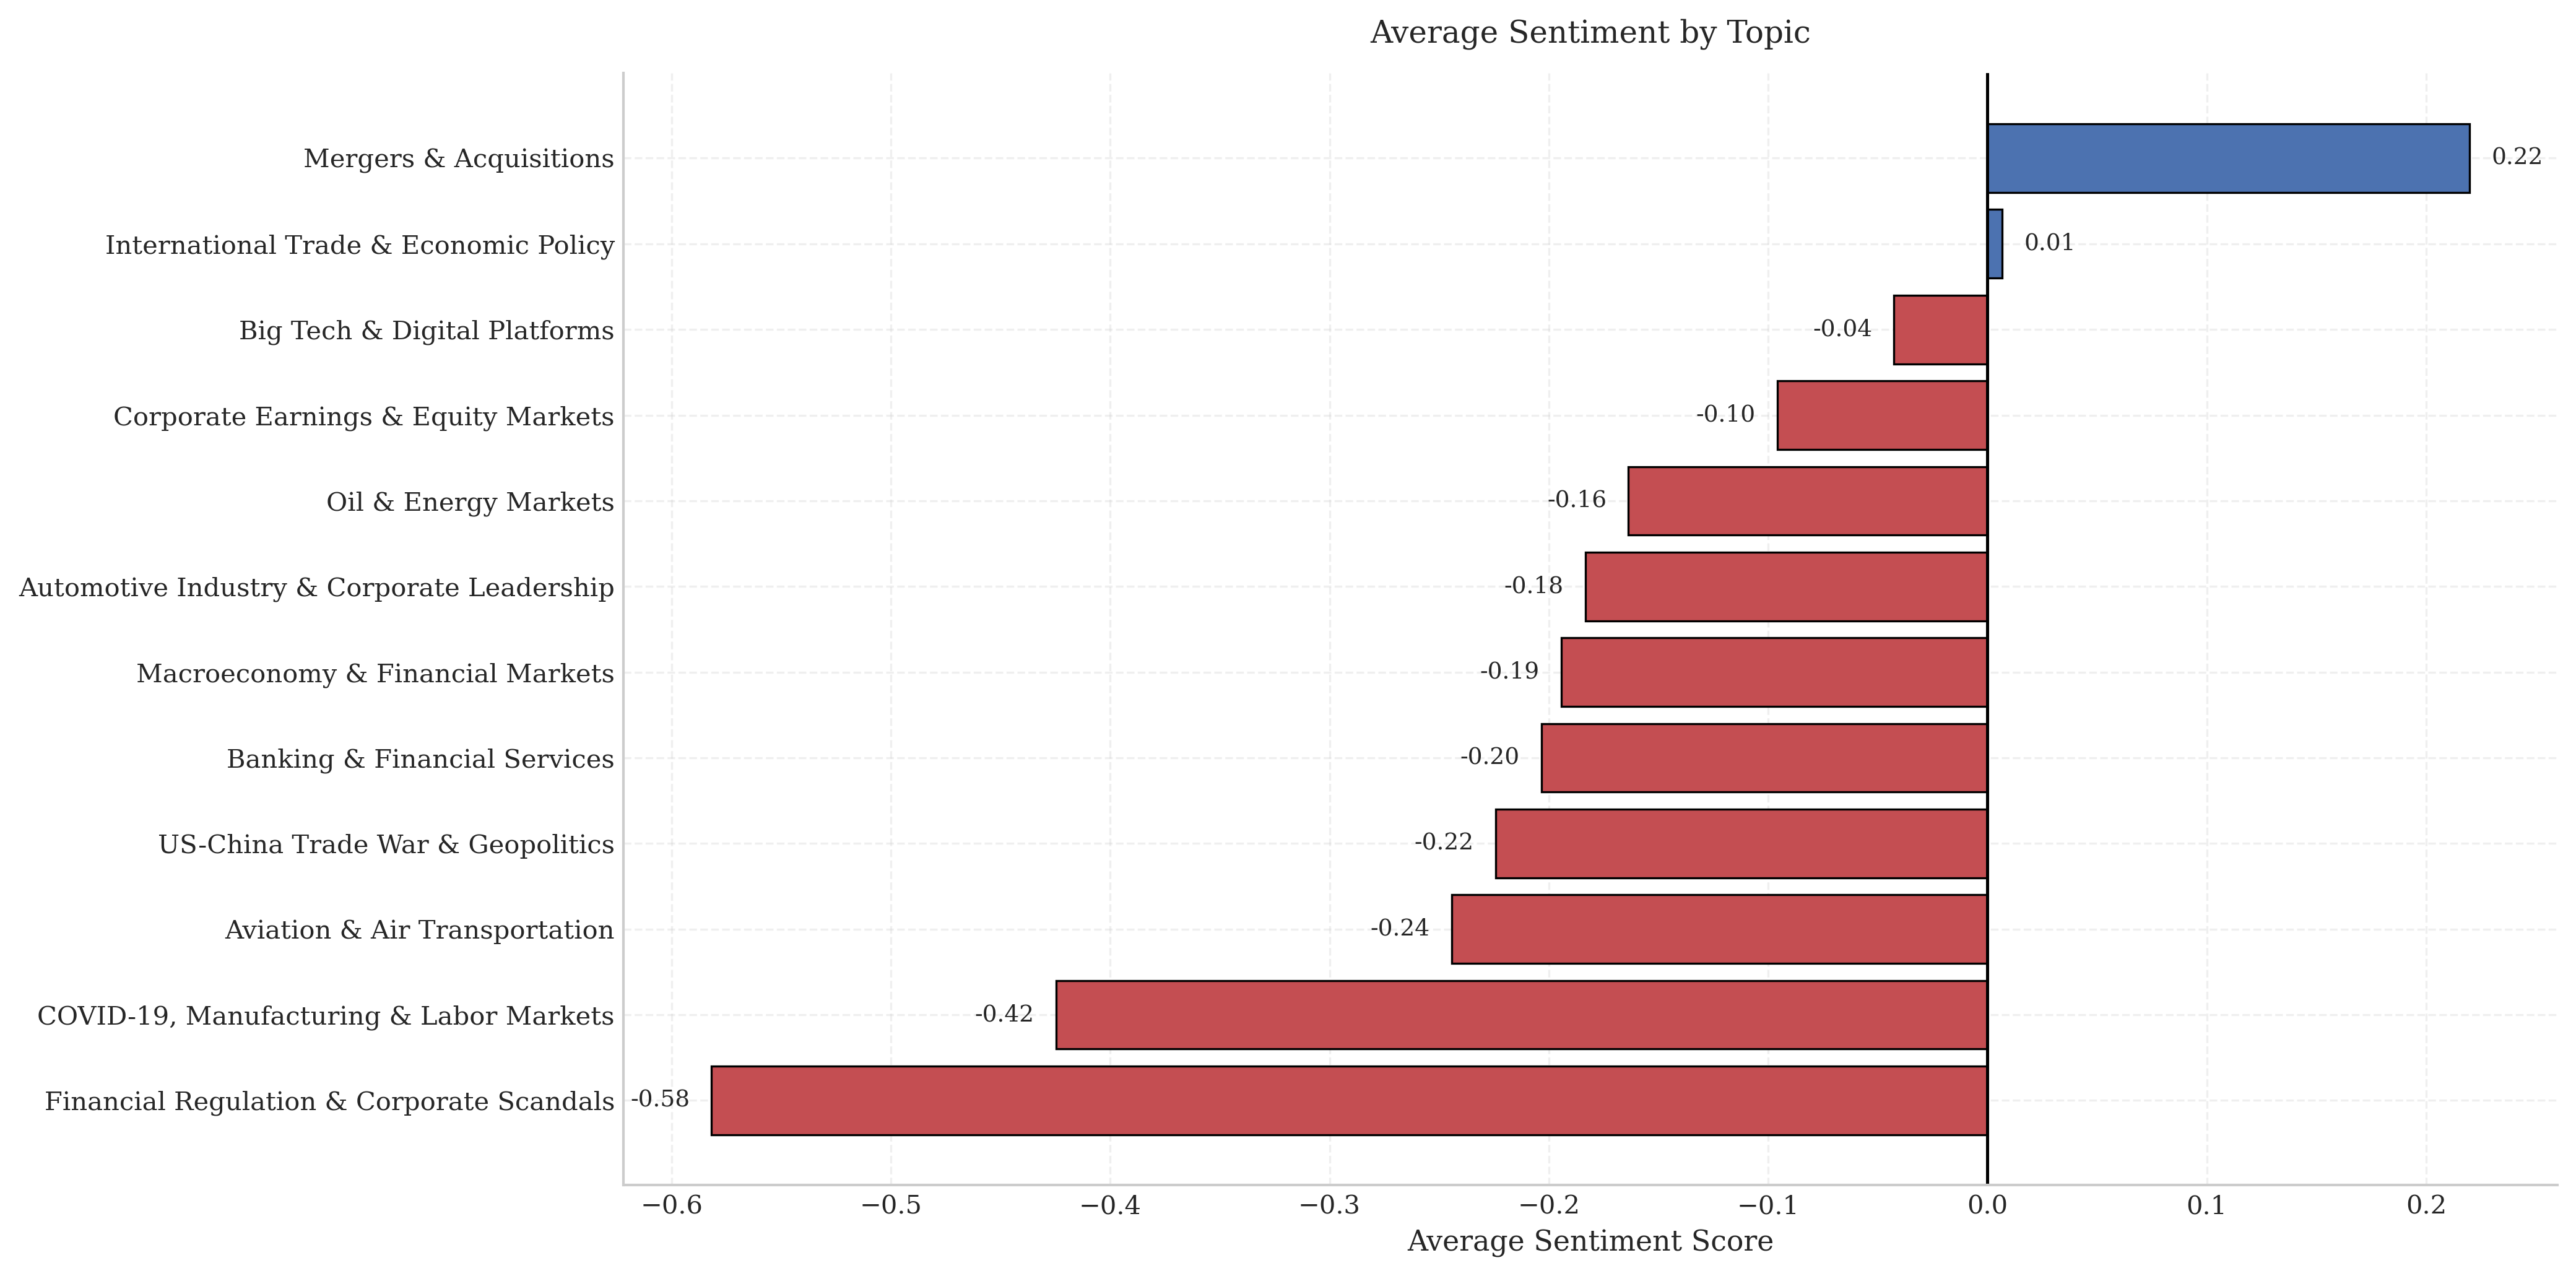

In [26]:
plot_sentiment_by_topic(
    df,
    save_path=
    "/Users/zhengbinheng/Desktop/topic-specific-sentiment/results/figures/sentiment_by_topic.png"
)

In [27]:
print(
    "Most Negative Topic:"
)

print(
    avg_sentiment.index[0],
    avg_sentiment.iloc[0]
)

print()

print(
    "Most Positive Topic:"
)

print(
    avg_sentiment.index[-1],
    avg_sentiment.iloc[-1]
)

Most Negative Topic:
Financial Regulation & Corporate Scandals -0.5817184643510055

Most Positive Topic:
Mergers & Acquisitions 0.21975992613111728


Topic Sentiment Table

In [28]:
topic_sentiment = pd.crosstab(
    df["topic_name"],
    df["sentiment"]
)

topic_sentiment

sentiment,negative,neutral,positive
topic_name,,,
Automotive Industry & Corporate Leadership,1413,1132,800
Aviation & Air Transportation,1183,430,634
Banking & Financial Services,1225,550,718
Big Tech & Digital Platforms,1287,925,1144
"COVID-19, Manufacturing & Labor Markets",1703,375,576
Corporate Earnings & Equity Markets,1221,165,993
Financial Regulation & Corporate Scandals,1917,492,326
International Trade & Economic Policy,954,463,970
Macroeconomy & Financial Markets,2205,251,1447


In [29]:
topic_sentiment_pct = (
    pd.crosstab(
        df["topic_name"],
        df["sentiment"],
        normalize="index"
    ) * 100
)

topic_sentiment_pct.round(2)

sentiment,negative,neutral,positive
topic_name,,,
Automotive Industry & Corporate Leadership,42.24,33.84,23.92
Aviation & Air Transportation,52.65,19.14,28.22
Banking & Financial Services,49.14,22.06,28.80
Big Tech & Digital Platforms,38.35,27.56,34.09
"COVID-19, Manufacturing & Labor Markets",64.17,14.13,21.70
Corporate Earnings & Equity Markets,51.32,6.94,41.74
Financial Regulation & Corporate Scandals,70.09,17.99,11.92
International Trade & Economic Policy,39.97,19.40,40.64
Macroeconomy & Financial Markets,56.50,6.43,37.07


In [30]:
topic_sentiment_pct.to_csv(
    "/Users/zhengbinheng/Desktop/topic-specific-sentiment/results/tables/topic_sentiment_pct.csv"
)

Negative Probability Ranking

In [31]:
negative_rank = (
    df.groupby("topic_name")
      ["negative_prob"]
      .mean()
      .sort_values(
          ascending=False
      )
)

negative_rank

topic_name
Financial Regulation & Corporate Scandals     0.632747
COVID-19, Manufacturing & Labor Markets       0.606224
Macroeconomy & Financial Markets              0.554147
Corporate Earnings & Equity Markets           0.504105
Aviation & Air Transportation                 0.503582
Oil & Energy Markets                          0.480188
Banking & Financial Services                  0.471051
US-China Trade War & Geopolitics              0.463235
Automotive Industry & Corporate Leadership    0.401436
International Trade & Economic Policy         0.381899
Big Tech & Digital Platforms                  0.364469
Mergers & Acquisitions                        0.250240
Name: negative_prob, dtype: float64

In [32]:
negative_rank.to_csv(
    "/Users/zhengbinheng/Desktop/topic-specific-sentiment/results/tables/negative_rank.csv"
)

Most Important Topics

In [33]:
TOPICS = [
    "COVID-19, Manufacturing & Labor Markets",
    "Big Tech & Digital Platforms",
    "Mergers & Acquisitions"
]

Figure 3: Topic-Specific Sentiment Dynamics

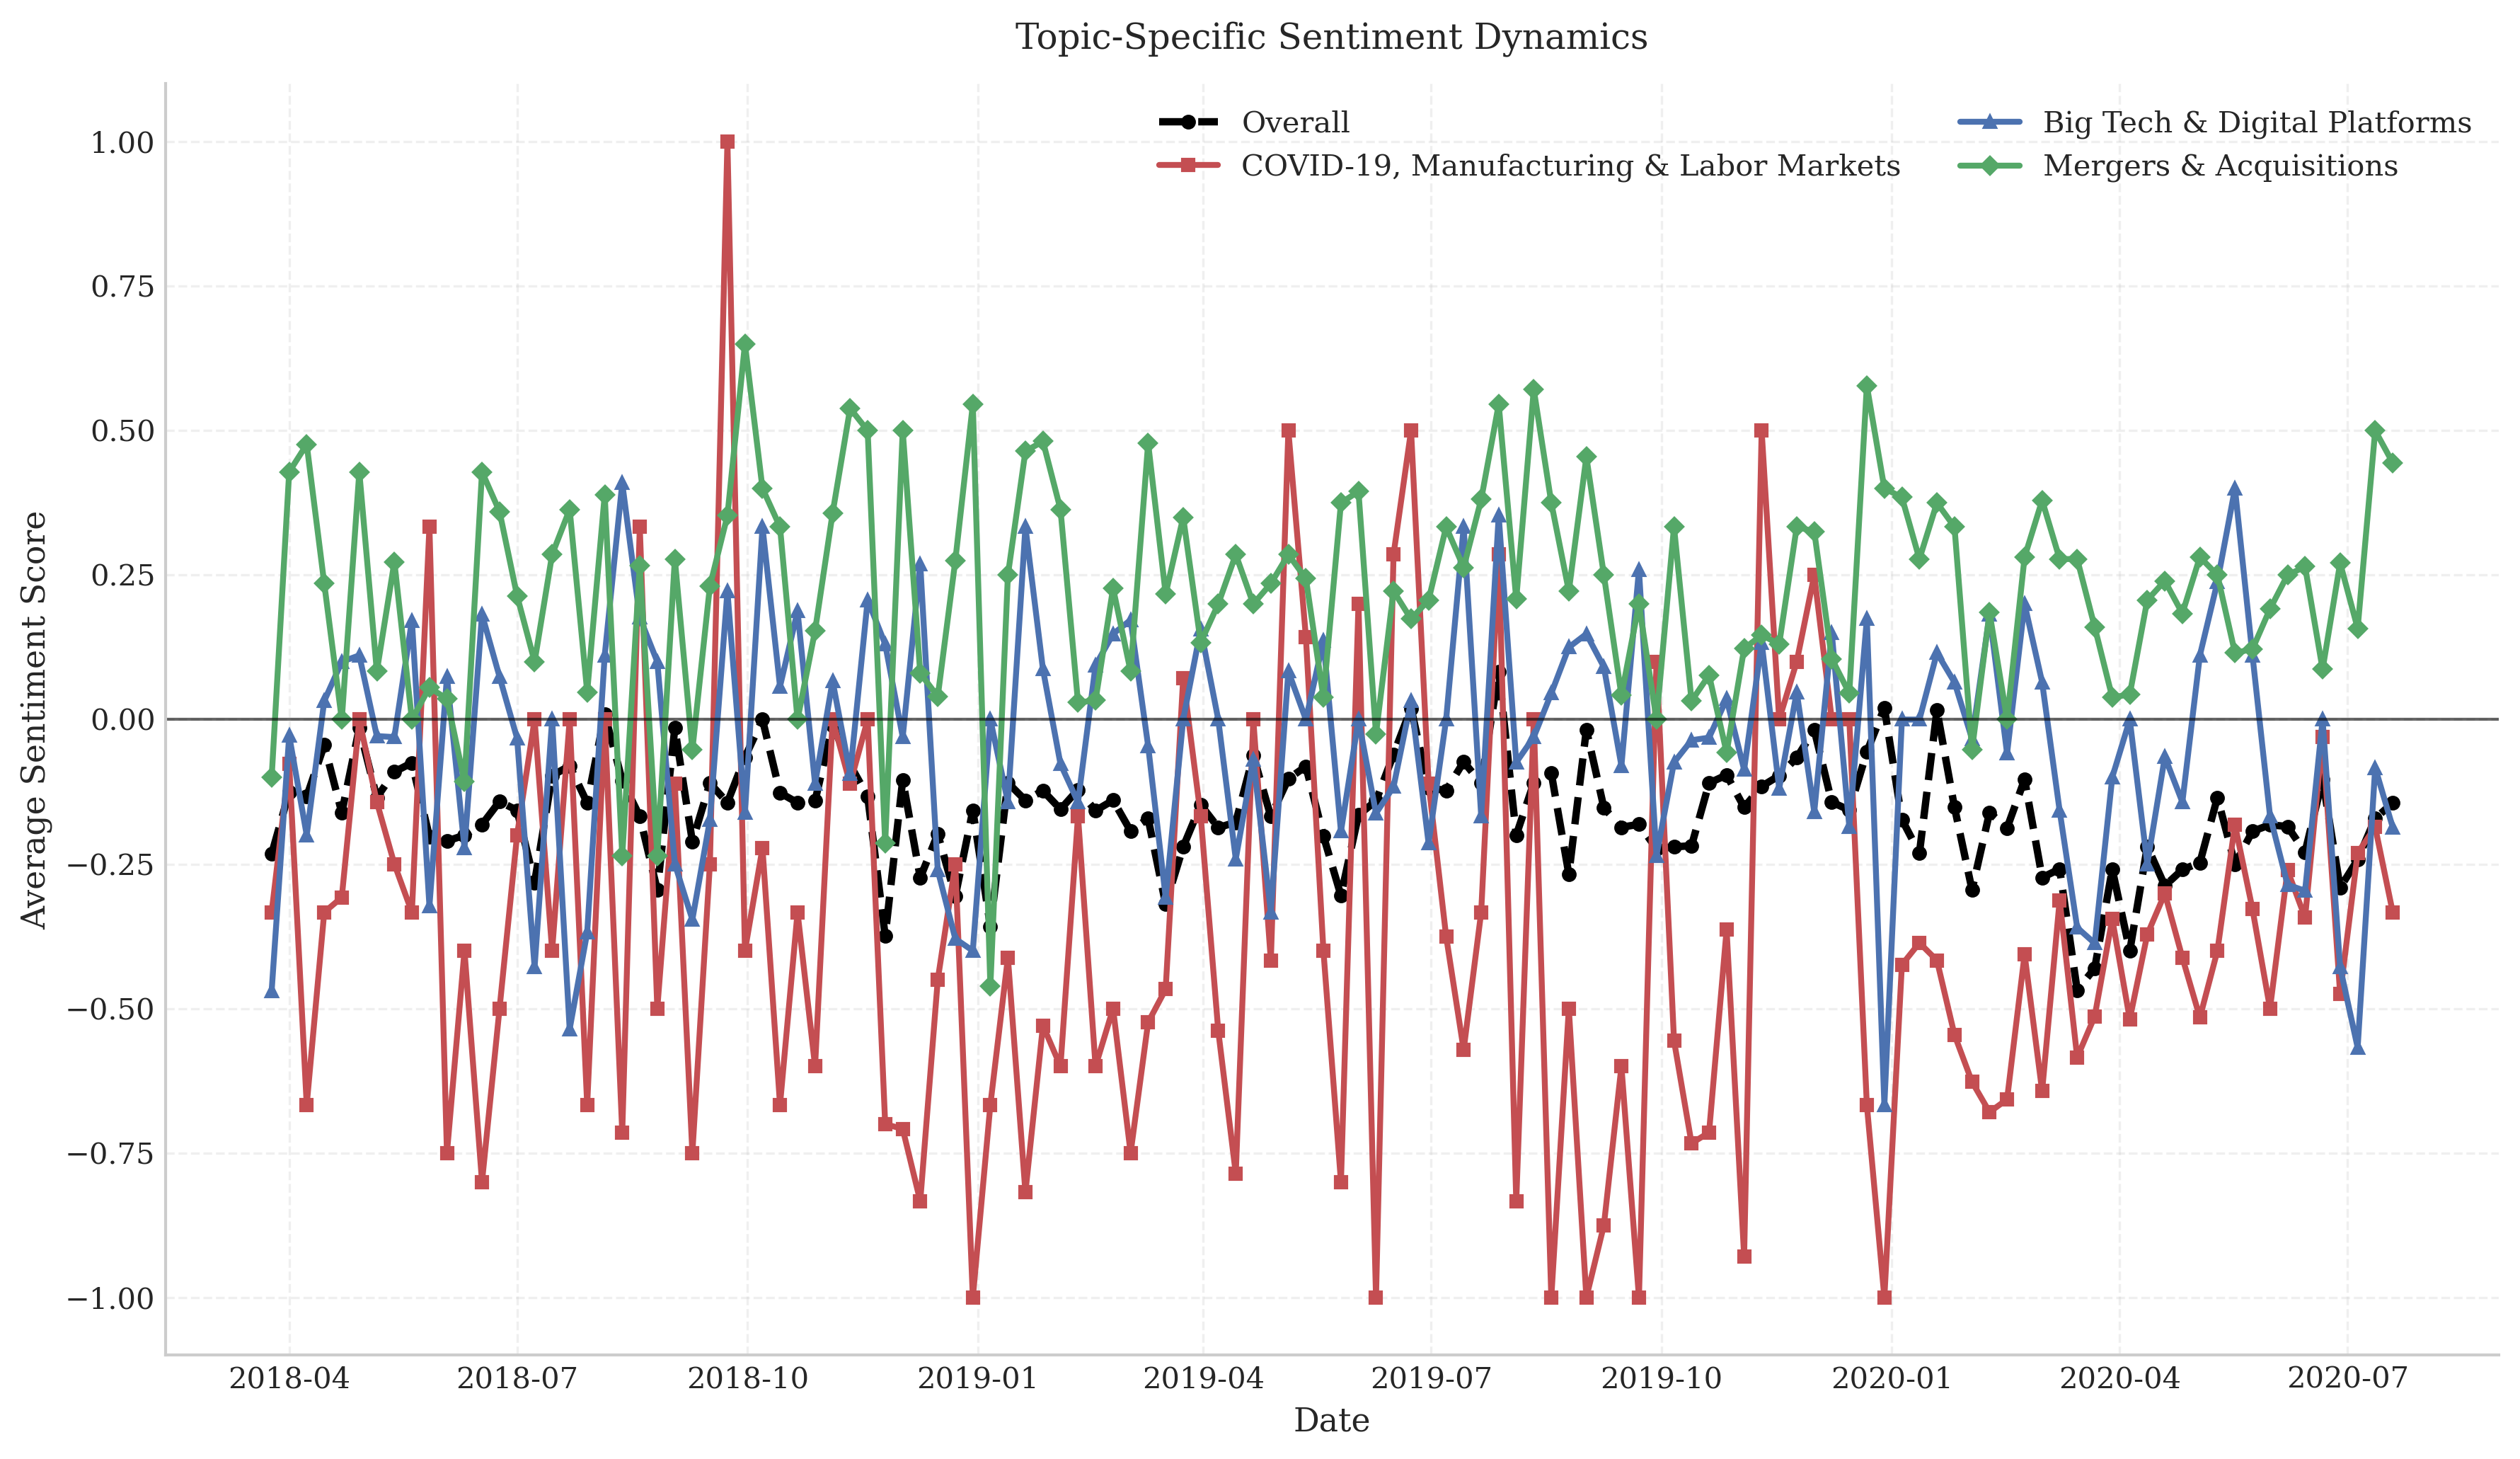

In [34]:
plot_sentiment_dynamics(
    df,
    topics=TOPICS,
    freq="W",
    save_path=
    "/Users/zhengbinheng/Desktop/topic-specific-sentiment/results/figures/sentiment_dynamics.png"
)

Figure 4: Topic Sentiment Heatmap

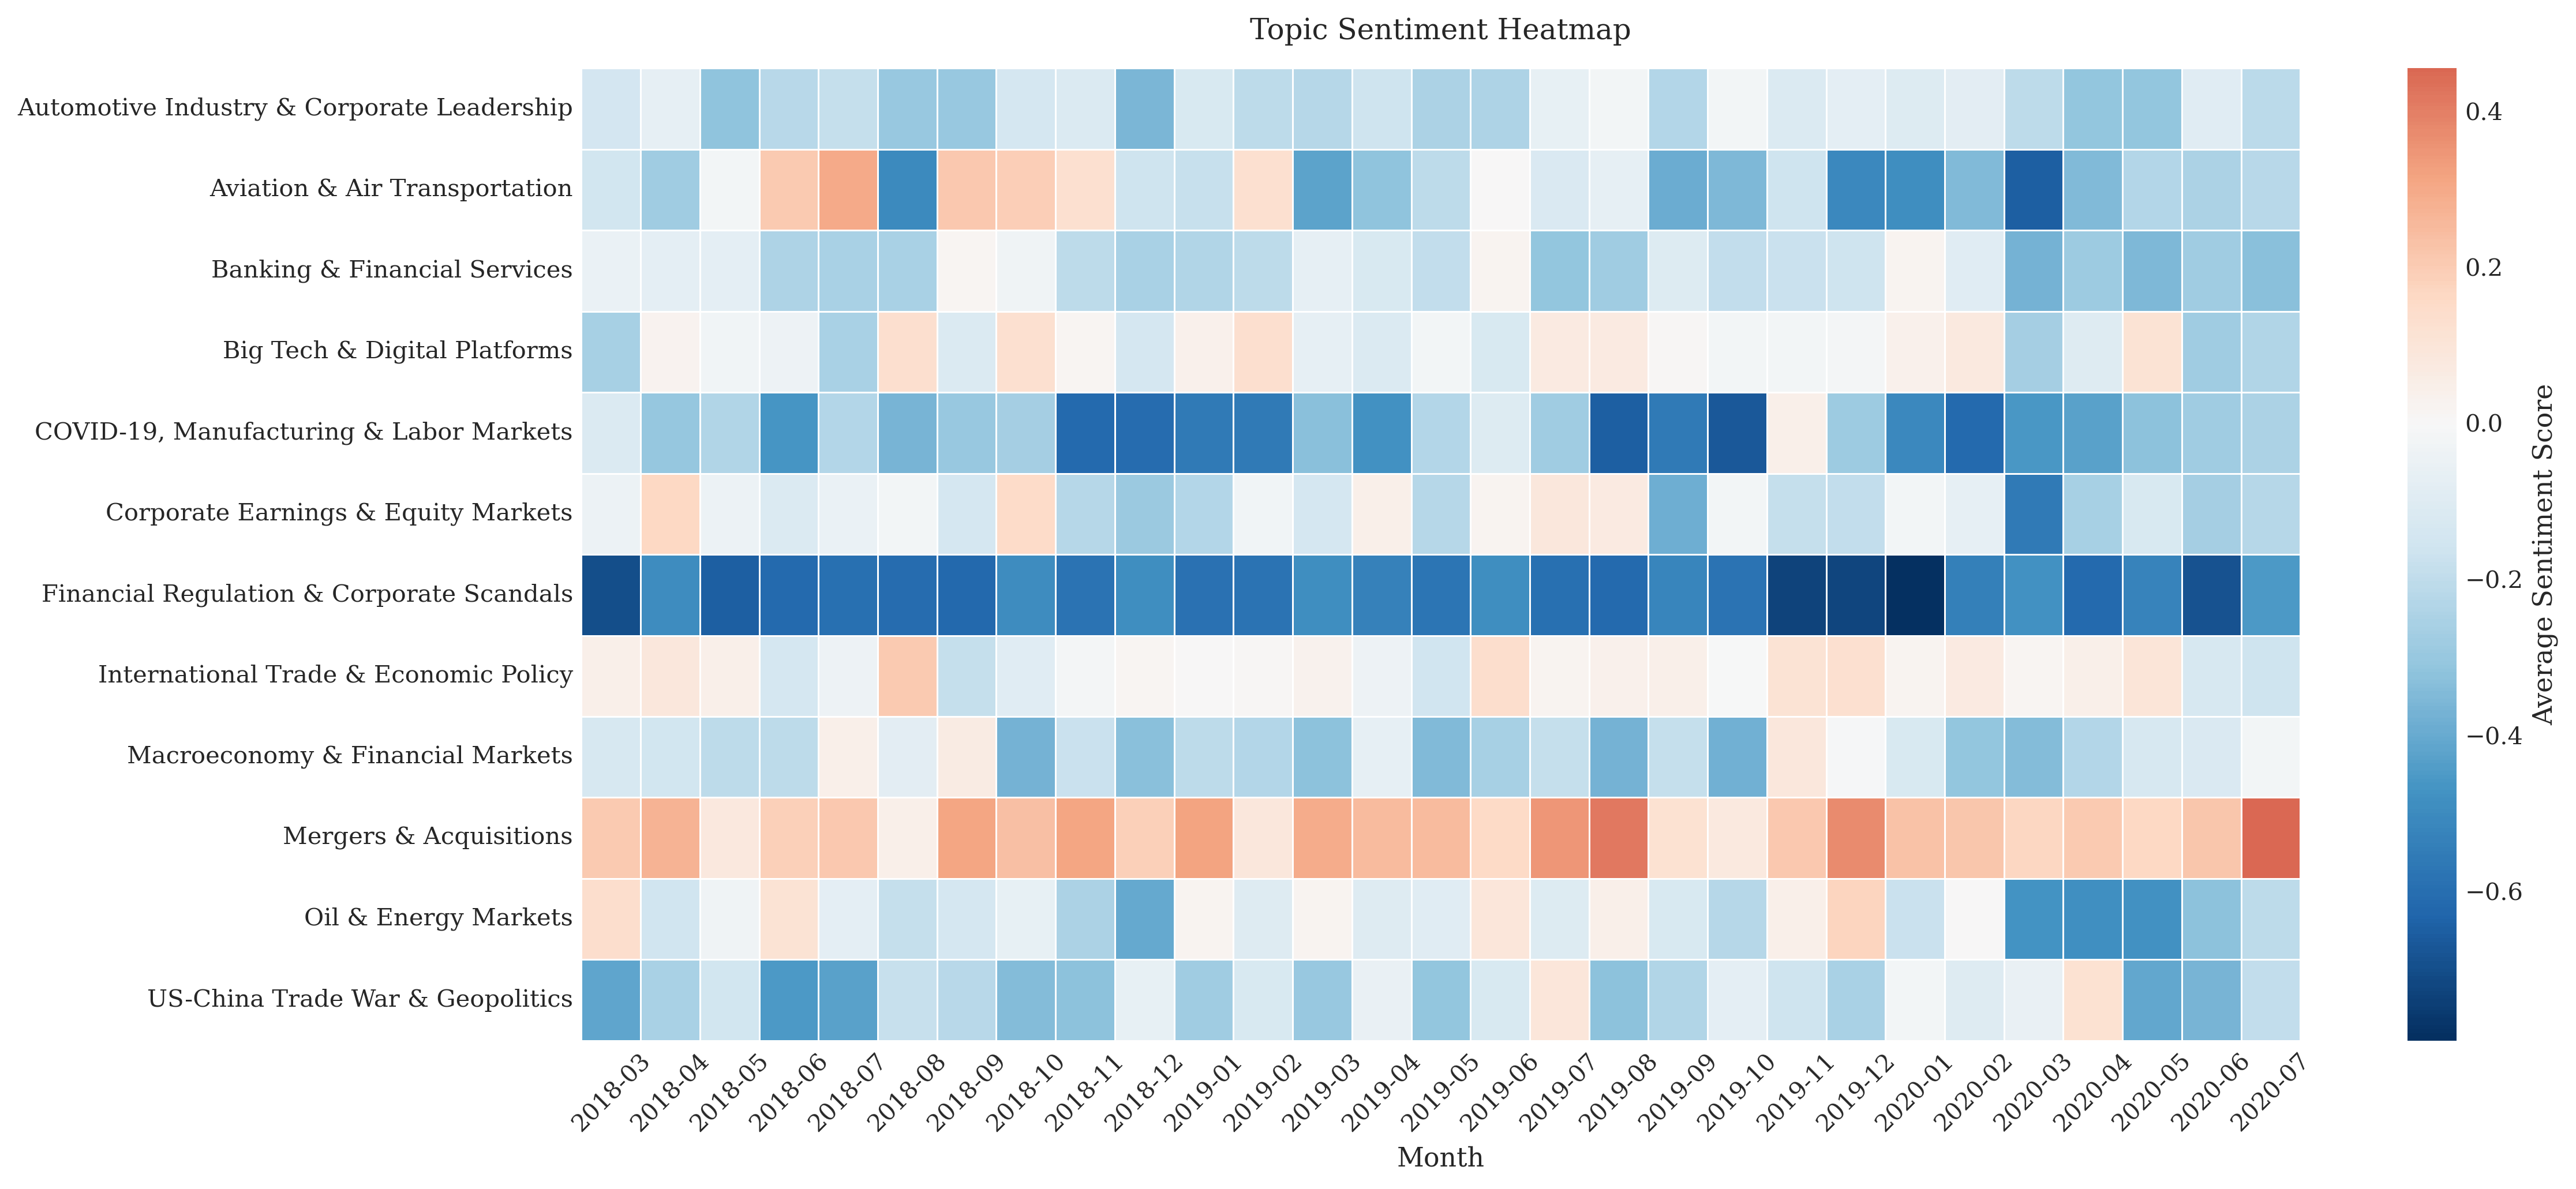

In [35]:
plot_topic_sentiment_heatmap(
    df,
    save_path=
    "/Users/zhengbinheng/Desktop/topic-specific-sentiment/results/figures/topic_sentiment_heatmap.png"
)

Figure 5: Sentiment Confidence

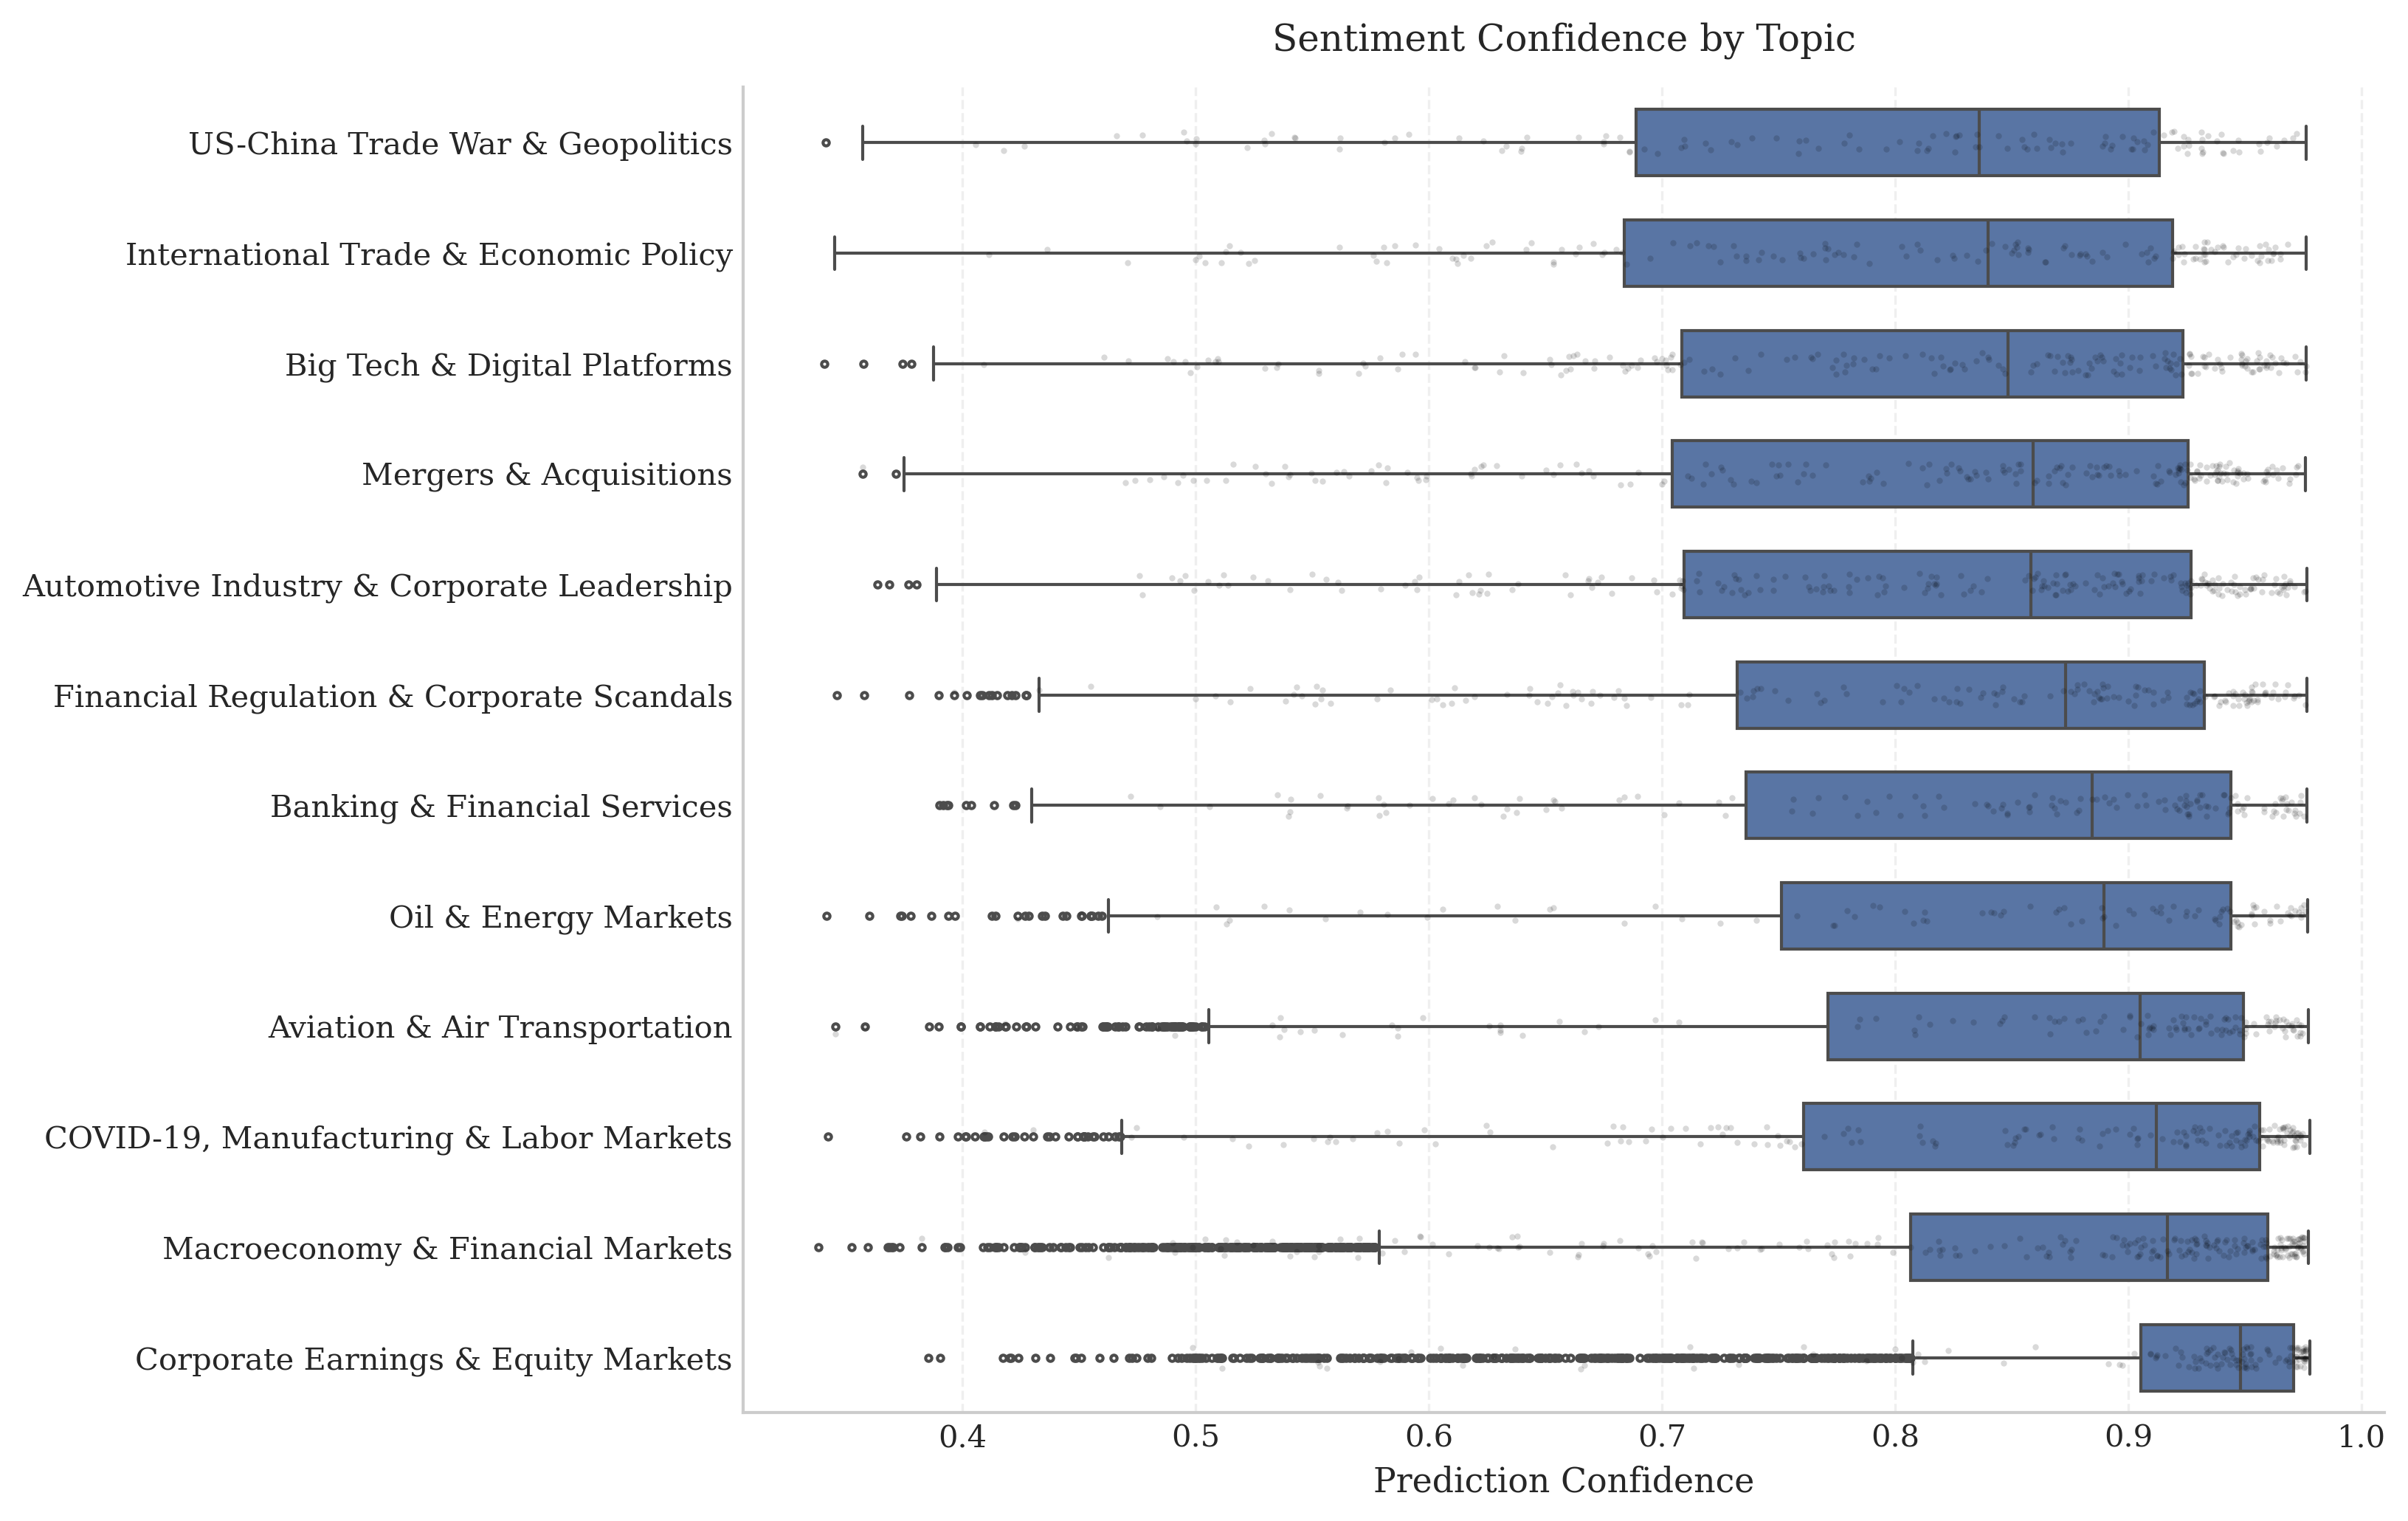

In [36]:
plot_sentiment_confidence(
    df,
    save_path=
    "/Users/zhengbinheng/Desktop/topic-specific-sentiment/results/figures/sentiment_confidence.png"
)

Confidence Summary

In [37]:
df["confidence"] = (
    df[
        [
            "positive_prob",
            "negative_prob",
            "neutral_prob"
        ]
    ]
    .max(axis=1)
)

In [38]:
confidence_summary = (
    df.groupby("topic_name")
    ["confidence"]
    .mean()
    .sort_values()
)

confidence_summary

topic_name
US-China Trade War & Geopolitics              0.789207
International Trade & Economic Policy         0.789984
Big Tech & Digital Platforms                  0.803711
Mergers & Acquisitions                        0.806001
Automotive Industry & Corporate Leadership    0.807219
Financial Regulation & Corporate Scandals     0.819907
Banking & Financial Services                  0.825464
Oil & Energy Markets                          0.829896
Aviation & Air Transportation                 0.843950
COVID-19, Manufacturing & Labor Markets       0.844073
Macroeconomy & Financial Markets              0.857018
Corporate Earnings & Equity Markets           0.901864
Name: confidence, dtype: float64

In [39]:
confidence_summary.to_csv(
    "/Users/zhengbinheng/Desktop/topic-specific-sentiment/results/tables/topic_confidence.csv"
)

Figure 6: Topic Similarity

In [40]:
import joblib

lda_model = joblib.load(
    "/Users/zhengbinheng/Desktop/topic-specific-sentiment/results/models/lda_model.pkl"
)

In [42]:
TOPIC_NAMES = {
    0: "Macroeconomy & Financial Markets",
    1: "Banking & Financial Services",
    2: "Aviation & Air Transportation",
    3: "US-China Trade War & Geopolitics",
    4: "Automotive Industry & Corporate Leadership",
    5: "International Trade & Economic Policy",
    6: "Big Tech & Digital Platforms",
    7: "COVID-19, Manufacturing & Labor Markets",
    8: "Corporate Earnings & Equity Markets",
    9: "Mergers & Acquisitions",
    10: "Oil & Energy Markets",
    11: "Financial Regulation & Corporate Scandals"
}

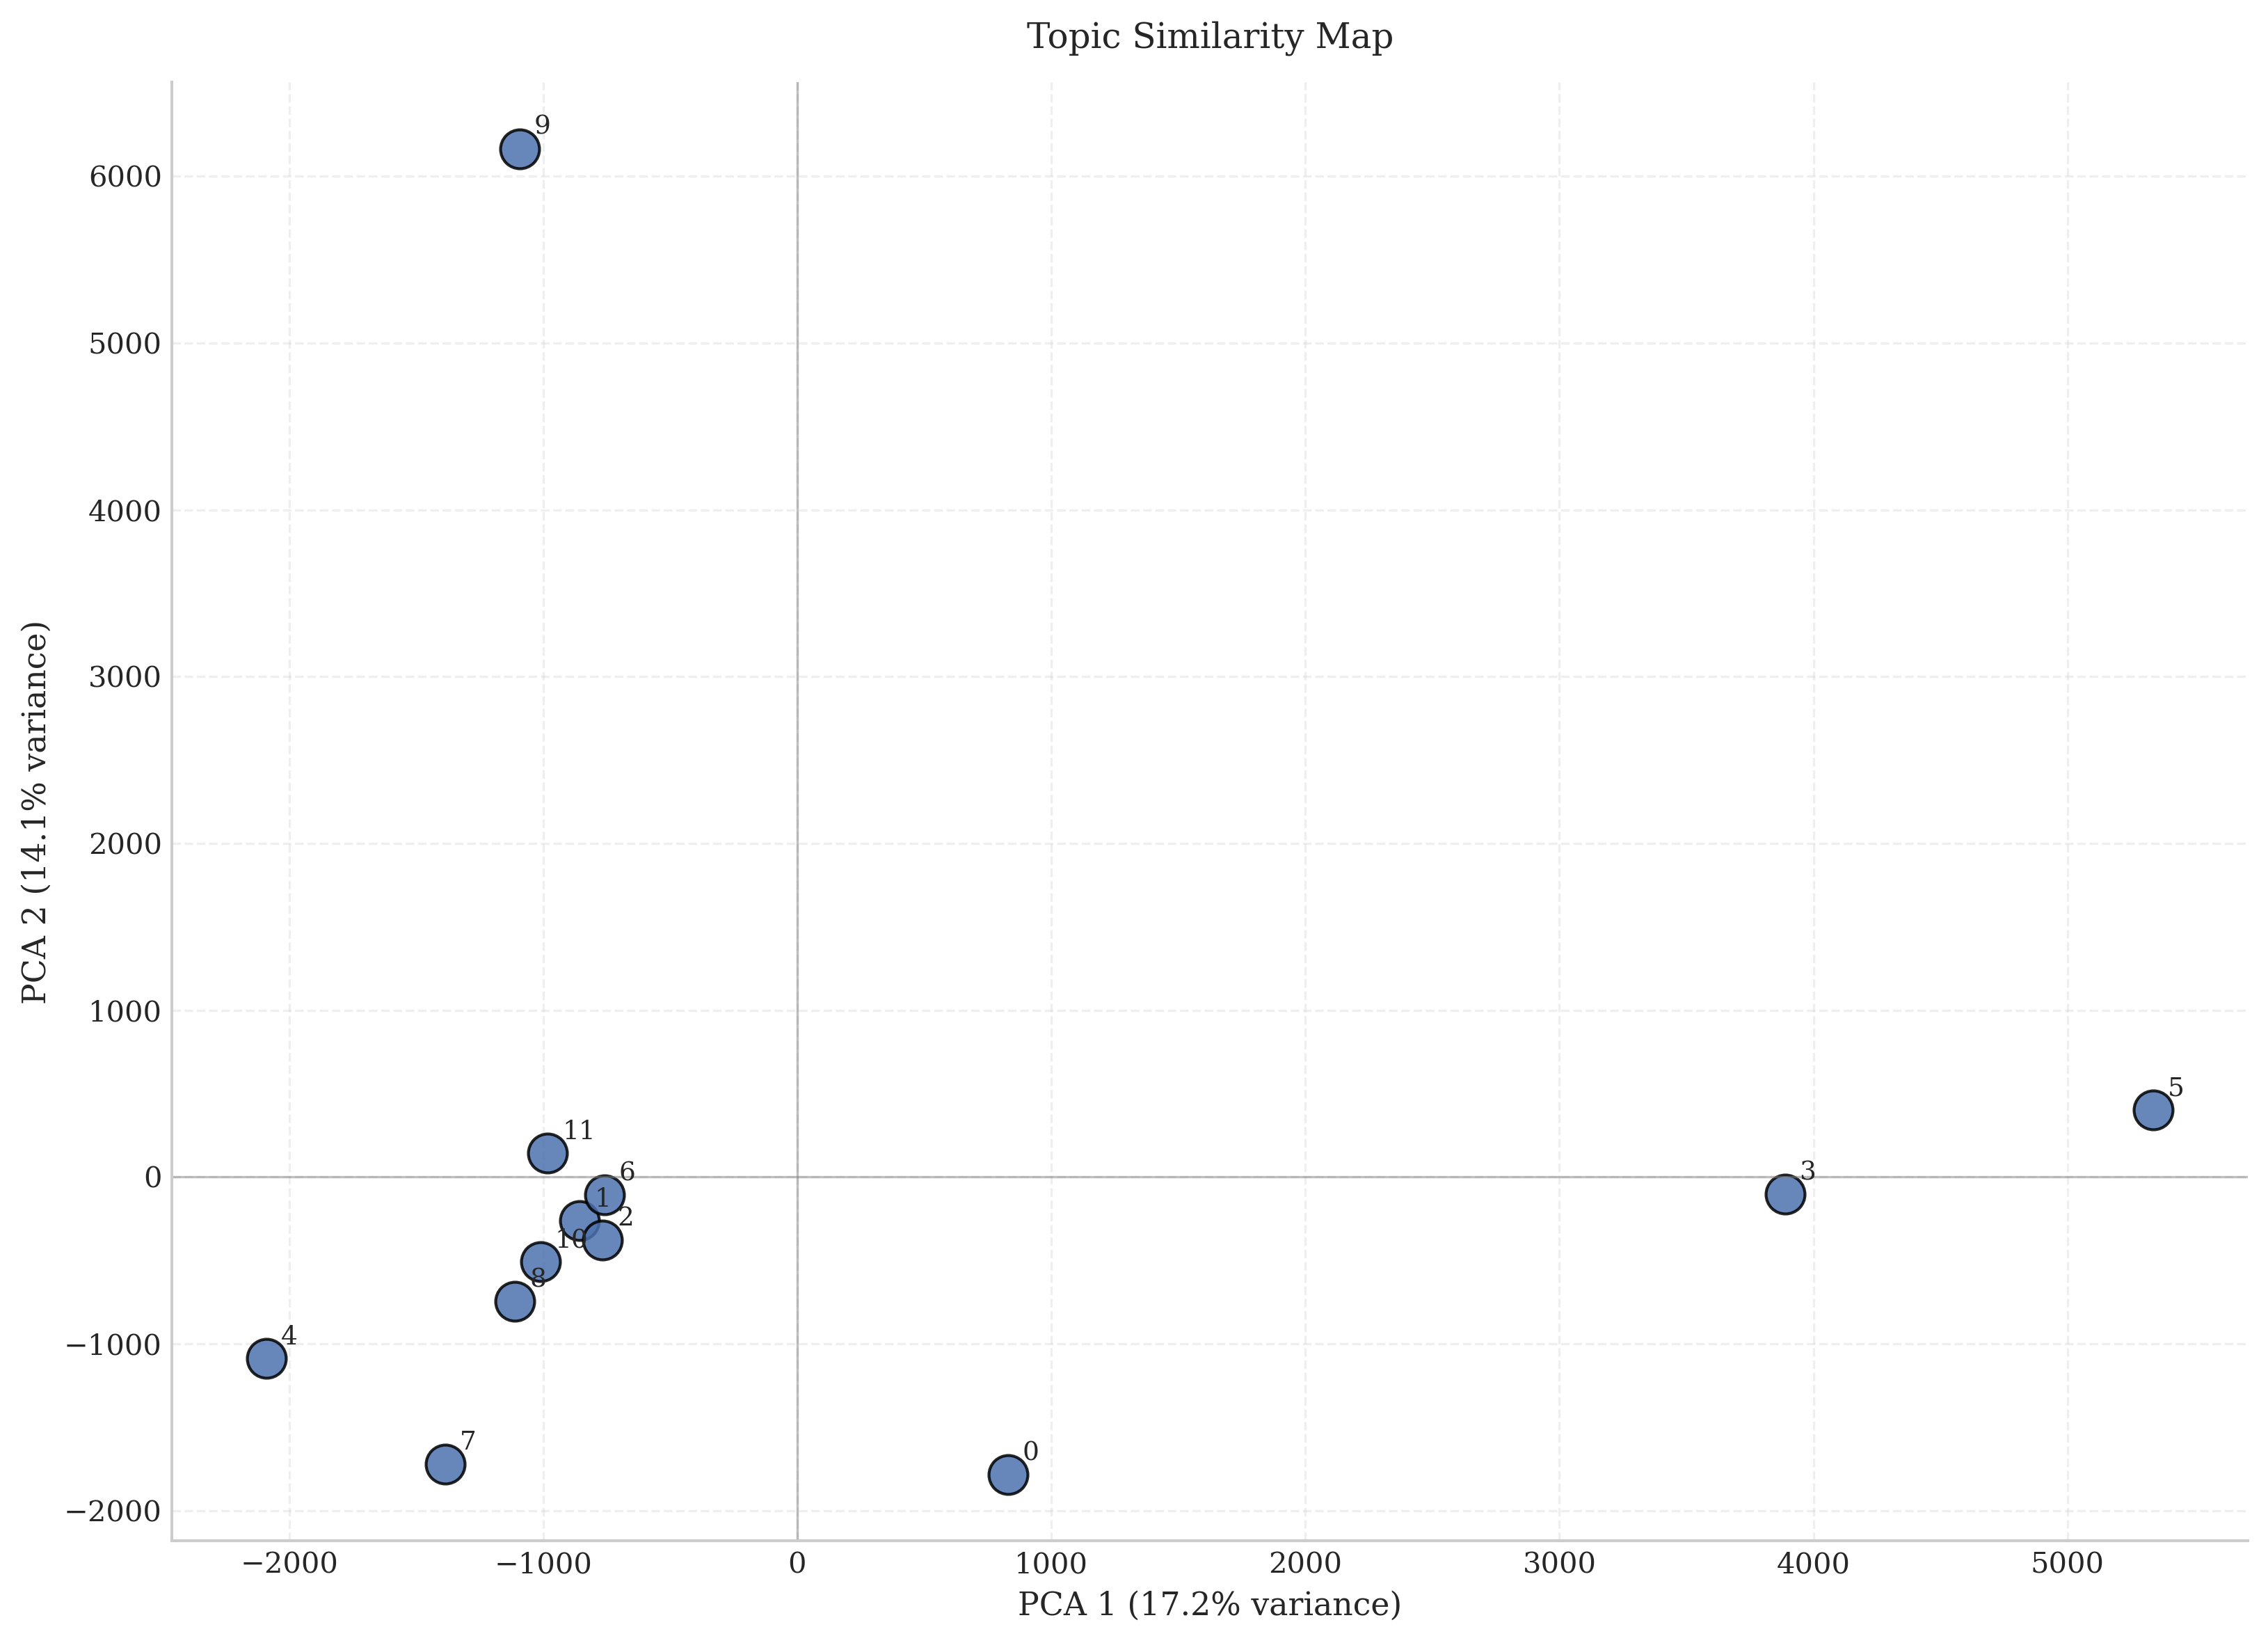

In [43]:
plot_topic_similarity(
    lda_model,
    TOPIC_NAMES,
    save_path=
    "/Users/zhengbinheng/Desktop/topic-specific-sentiment/results/figures/topic_similarity.png"
)